In [1]:
from pathlib import Path
import sqlite3
import pandas as pd

# Busca la raíz del proyecto desde la ubicación del notebook
ROOT = Path.cwd()

while ROOT != ROOT.parent and not (ROOT / "database").exists():
    ROOT = ROOT.parent

DB_PATH = ROOT / "database" / "air_quality.db"

print("Ruta de la base de datos:", DB_PATH)
print("¿La base existe?:", DB_PATH.exists())

conexion = sqlite3.connect(DB_PATH)

Ruta de la base de datos: /workspaces/etl-calidad-aire-india/database/air_quality.db
¿La base existe?: True


In [2]:
consulta = """
SELECT
    f.measurement_id,
    c.city_name AS City,
    d.full_datetime AS Datetime,
    f.pm25 AS "PM2.5",
    f.pm10 AS PM10,
    f.no_value AS NO,
    f.no2 AS NO2,
    f.nox AS NOx,
    f.nh3 AS NH3,
    f.co AS CO,
    f.so2 AS SO2,
    f.o3 AS O3,
    f.aqi AS AQI,
    a.aqi_bucket AS AQI_Bucket,
    d.year AS Year,
    d.month AS Month,
    d.day AS Day,
    d.quarter AS Quarter,
    d.day_of_week AS Day_of_Week
FROM fact_air_quality AS f
INNER JOIN dim_city AS c
    ON f.city_id = c.city_id
INNER JOIN dim_date AS d
    ON f.date_id = d.date_id
INNER JOIN dim_aqi AS a
    ON f.aqi_id = a.aqi_id
ORDER BY f.measurement_id
"""

df_bd = pd.read_sql_query(consulta, conexion)
df_bd["Datetime"] = pd.to_datetime(df_bd["Datetime"])

print("Dimensiones de los datos consultados desde SQLite:", df_bd.shape)

df_bd.head()

Dimensiones de los datos consultados desde SQLite: (18265, 19)


,measurement_id,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Year,Month,Day,Quarter,Day_of_Week
0,1,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor,2015,1,1,1,Thursday
1,2,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor,2015,1,1,1,Thursday
2,3,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor,2015,1,1,1,Thursday
3,4,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor,2015,1,1,1,Thursday
4,5,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor,2015,1,1,1,Thursday


In [3]:
print("Información general de los datos consultados desde SQLite:")
df_bd.info()

print("\nValores nulos por columna:")
print(df_bd.isnull().sum())

print("\nCantidad de filas duplicadas:")
print(df_bd.duplicated().sum())

Información general de los datos consultados desde SQLite:
<class 'pandas.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   measurement_id  18265 non-null  int64         
 1   City            18265 non-null  str           
 2   Datetime        18265 non-null  datetime64[us]
 3   PM2.5           18265 non-null  float64       
 4   PM10            18265 non-null  float64       
 5   NO              18265 non-null  float64       
 6   NO2             18265 non-null  float64       
 7   NOx             18265 non-null  float64       
 8   NH3             18265 non-null  float64       
 9   CO              18265 non-null  float64       
 10  SO2             18265 non-null  float64       
 11  O3              18265 non-null  float64       
 12  AQI             18265 non-null  float64       
 13  AQI_Bucket      18265 non-null  str           
 14  Year  

In [4]:
variables_numericas = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "AQI"
]

estadisticas_descriptivas = (
    df_bd[variables_numericas]
    .describe()
    .T
)

estadisticas_descriptivas

,count,mean,std,min,25%,50%,75%,max
PM2.5,18265.0,250.597695,144.460292,0.0,125.70,251.0,376.20,499.9
PM10,18265.0,299.442491,173.479906,0.0,150.10,300.3,450.00,600.0
NO,18265.0,100.481035,57.774795,0.0,50.60,100.2,151.00,200.0
NO2,18265.0,75.415916,43.460066,0.0,37.70,76.0,113.20,150.0
NOx,18265.0,125.964079,72.403893,0.0,63.10,126.2,188.90,250.0
NH3,18265.0,25.065042,14.452019,0.0,12.60,25.3,37.60,50.0
CO,18265.0,5.002451,2.889439,0.0,2.49,5.0,7.51,10.0
SO2,18265.0,49.835839,28.988739,0.0,24.40,49.9,75.10,100.0
O3,18265.0,100.406740,57.591436,0.0,50.60,100.7,150.40,200.0
AQI,18265.0,317.505212,113.894816,26.9,207.10,331.6,414.00,500.0


In [5]:
consulta_ciudades = """
SELECT
    c.city_name AS City,
    COUNT(*) AS cantidad_registros
FROM fact_air_quality AS f
INNER JOIN dim_city AS c
    ON f.city_id = c.city_id
GROUP BY c.city_name
ORDER BY cantidad_registros DESC, City
"""

registros_por_ciudad = pd.read_sql_query(
    consulta_ciudades,
    conexion
)

print("Cantidad de registros por ciudad:")
registros_por_ciudad

consulta_categorias = """
SELECT
    a.aqi_bucket AS AQI_Bucket,
    COUNT(*) AS cantidad_registros
FROM fact_air_quality AS f
INNER JOIN dim_aqi AS a
    ON f.aqi_id = a.aqi_id
GROUP BY a.aqi_bucket
ORDER BY cantidad_registros DESC
"""

registros_por_categoria = pd.read_sql_query(
    consulta_categorias,
    conexion
)

print("Cantidad de registros por categoría AQI:")
registros_por_categoria

Cantidad de registros por ciudad:
Cantidad de registros por categoría AQI:


,AQI_Bucket,cantidad_registros
0,Very Poor,5501
1,Severe,5258
2,Moderate,4258
3,Poor,3129
4,Satisfactory,113
5,Good,6


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

consulta_aqi_ciudad = """
SELECT
    c.city_name AS City,
    ROUND(AVG(f.aqi), 2) AS AQI_promedio,
    ROUND(MIN(f.aqi), 2) AS AQI_minimo,
    ROUND(MAX(f.aqi), 2) AS AQI_maximo
FROM fact_air_quality AS f
INNER JOIN dim_city AS c
    ON f.city_id = c.city_id
GROUP BY c.city_name
ORDER BY AQI_promedio DESC
"""

aqi_por_ciudad = pd.read_sql_query(
    consulta_aqi_ciudad,
    conexion
)

print("Resumen del AQI por ciudad:")
aqi_por_ciudad

Resumen del AQI por ciudad:


,City,AQI_promedio,AQI_minimo,AQI_maximo
0,Mumbai,318.18,37.7,500.0
1,Kolkata,317.73,39.6,500.0
2,Delhi,317.72,65.2,500.0
3,Bangalore,317.27,26.9,500.0
4,Chennai,316.62,44.7,500.0


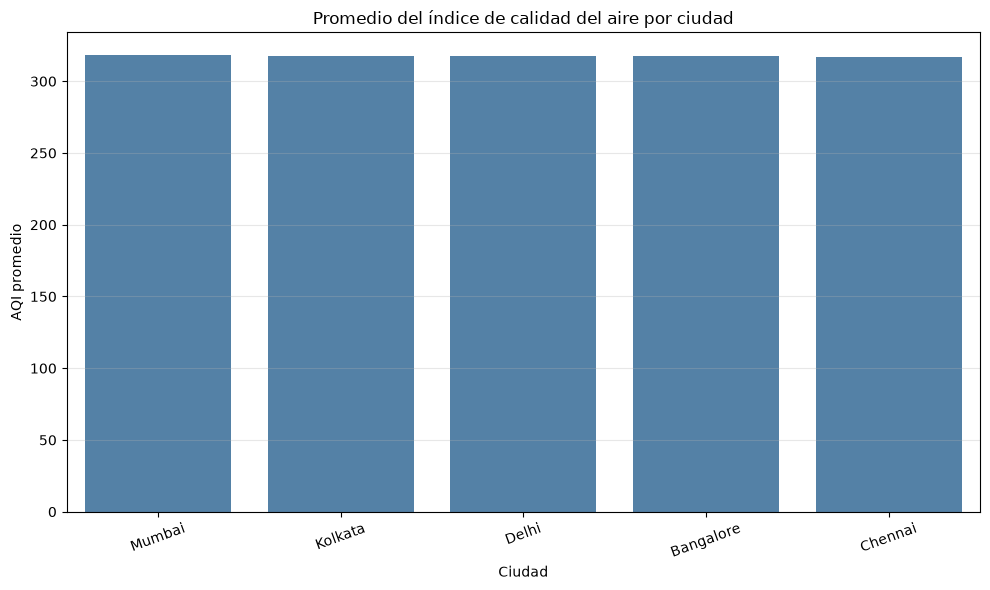

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=aqi_por_ciudad,
    x="City",
    y="AQI_promedio",
    color="steelblue"
)

plt.title("Promedio del índice de calidad del aire por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("AQI promedio")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

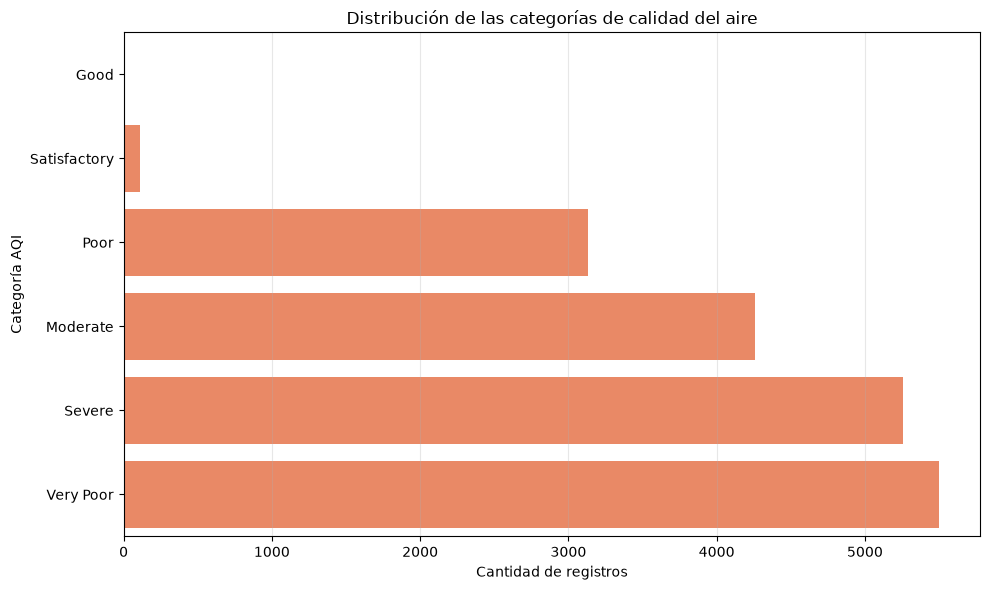

In [8]:
categorias_grafica = registros_por_categoria.sort_values(
    "cantidad_registros",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=categorias_grafica,
    x="cantidad_registros",
    y="AQI_Bucket",
    color="coral"
)

plt.title("Distribución de las categorías de calidad del aire")
plt.xlabel("Cantidad de registros")
plt.ylabel("Categoría AQI")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
consulta_aqi_anual = """
SELECT
    d.year AS Year,
    c.city_name AS City,
    ROUND(AVG(f.aqi), 2) AS AQI_promedio
FROM fact_air_quality AS f
INNER JOIN dim_city AS c
    ON f.city_id = c.city_id
INNER JOIN dim_date AS d
    ON f.date_id = d.date_id
GROUP BY d.year, c.city_name
ORDER BY d.year, c.city_name
"""

aqi_anual = pd.read_sql_query(
    consulta_aqi_anual,
    conexion
)

aqi_anual.head()

,Year,City,AQI_promedio
0,2015,Bangalore,311.19
1,2015,Chennai,316.06
2,2015,Delhi,318.05
3,2015,Kolkata,319.98
4,2015,Mumbai,312.04


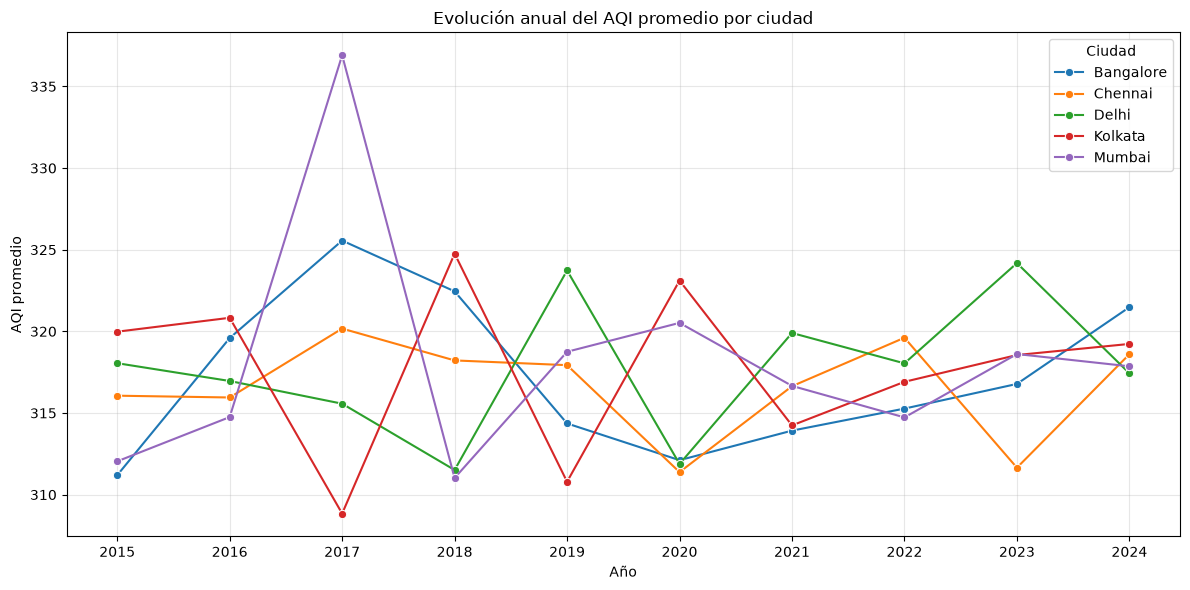

In [10]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=aqi_anual,
    x="Year",
    y="AQI_promedio",
    hue="City",
    marker="o"
)

plt.title("Evolución anual del AQI promedio por ciudad")
plt.xlabel("Año")
plt.ylabel("AQI promedio")
plt.xticks(sorted(aqi_anual["Year"].unique()))
plt.grid(alpha=0.3)
plt.legend(title="Ciudad")
plt.tight_layout()
plt.show()

In [11]:
consulta_correlacion = """
SELECT
    pm25 AS "PM2.5",
    pm10 AS PM10,
    no_value AS NO,
    no2 AS NO2,
    nox AS NOx,
    nh3 AS NH3,
    co AS CO,
    so2 AS SO2,
    o3 AS O3,
    aqi AS AQI
FROM fact_air_quality
"""

datos_correlacion = pd.read_sql_query(
    consulta_correlacion,
    conexion
)

matriz_correlacion = datos_correlacion.corr()
matriz_correlacion

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
PM2.5,1.000000,-0.024813,-0.003121,0.006602,0.002993,0.005980,0.009632,0.009056,0.008475,-0.009736
PM10,-0.024813,1.000000,0.002387,0.003604,-0.004637,0.000810,-0.007387,0.011537,-0.005494,0.229593
NO,-0.003121,0.002387,1.000000,-0.003365,0.001329,0.001598,-0.006056,-0.001321,-0.013673,0.002626
NO2,0.006602,0.003604,-0.003365,1.000000,0.001451,-0.006045,0.009833,-0.011502,0.003424,0.009928
NOx,0.002993,-0.004637,0.001329,0.001451,1.000000,-0.003423,-0.000832,-0.017316,0.005907,-0.007946
NH3,0.005980,0.000810,0.001598,-0.006045,-0.003423,1.000000,-0.003939,0.001580,-0.002883,0.000540
CO,0.009632,-0.007387,-0.006056,0.009833,-0.000832,-0.003939,1.000000,-0.004426,-0.001052,0.029899
SO2,0.009056,0.011537,-0.001321,-0.011502,-0.017316,0.001580,-0.004426,1.000000,0.000546,0.001141
O3,0.008475,-0.005494,-0.013673,0.003424,0.005907,-0.002883,-0.001052,0.000546,1.000000,0.061954
AQI,-0.009736,0.229593,0.002626,0.009928,-0.007946,0.000540,0.029899,0.001141,0.061954,1.000000


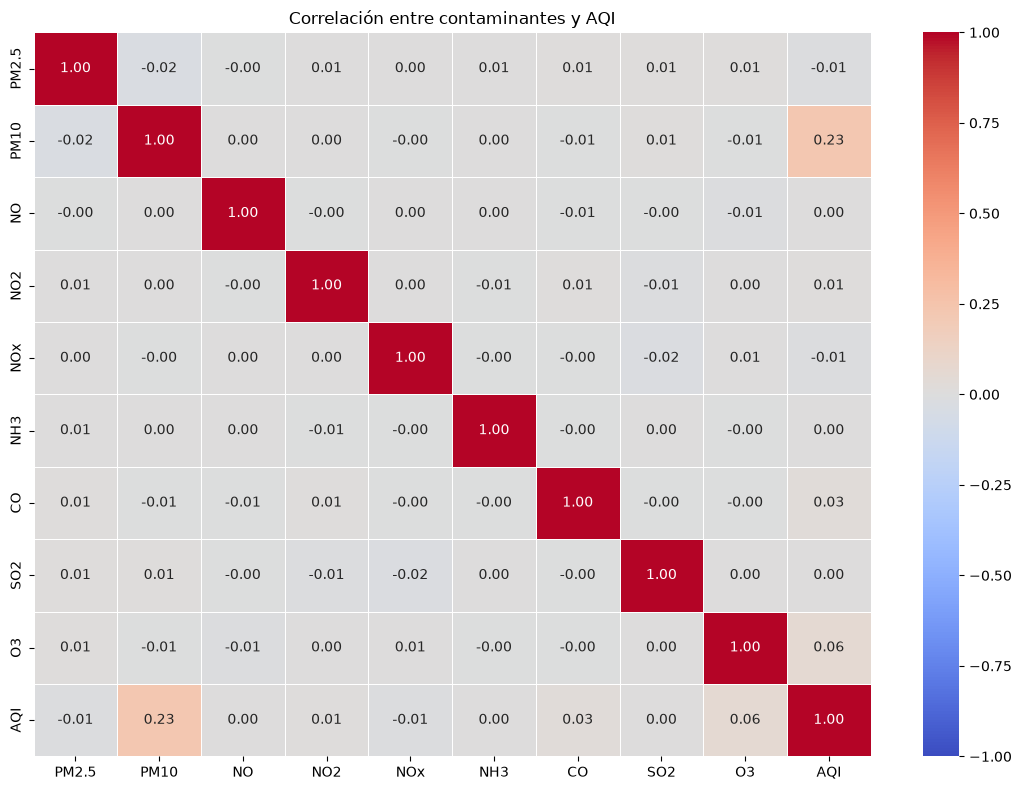

In [12]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre contaminantes y AQI")
plt.tight_layout()
plt.show()